<a href="https://colab.research.google.com/github/Erjg1012/sales_targeting-quota_setting/blob/main/Enfoque_Corporativo_Tradicional_(B2B_y_SaaS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cálculo de cuotas empleando prophet

empleamos estos modelos por su flexibilidad con la estacionalidad, además se va a emplear un crecimiento de 15% (Este dato podría obtenerse generando análisis, con el conocimiento de la general de la industria o un poco de ambos)

## configuración de libreiras y Gráficas

In [1]:
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Librerías para modelado
!pip install prophet
from prophet import Prophet

In [3]:
%matplotlib inline
sns.set_theme(style="whitegrid")

##Carga de los datos

In [6]:
df = pd.read_csv('train.csv', encoding='latin1')

# Convertir la fecha al formato correcto, especificando que el día va primero
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Filtrar las columnas necesarias para nuestro MVP de cuotas
df_ventas = df[['Order Date', 'Region', 'Sales']].copy()

# Agrupar por mes y región para ver el comportamiento histórico
df_mensual = df_ventas.groupby(['Region', pd.Grouper(key='Order Date', freq='ME')]).sum().reset_index()

print(df_mensual.head())

    Region Order Date     Sales
0  Central 2015-01-31  1533.966
1  Central 2015-02-28  1233.174
2  Central 2015-03-31  5827.602
3  Central 2015-04-30  3712.340
4  Central 2015-05-31  4044.522


##Uso del modelo

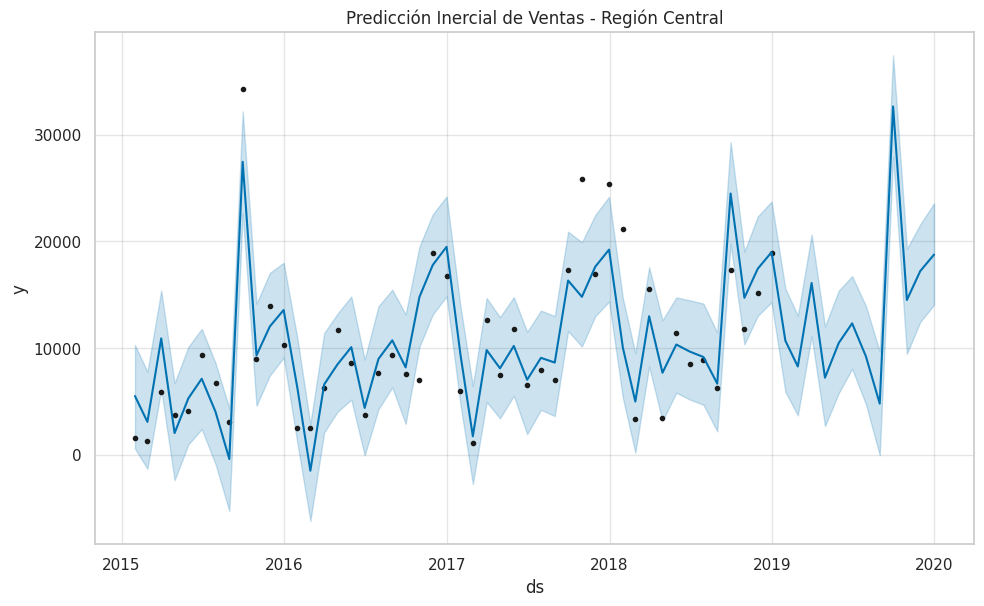

In [7]:
# Seleccionamos una región para el piloto
region_piloto = 'Central'
df_region = df_mensual[df_mensual['Region'] == region_piloto][['Order Date', 'Sales']].copy()

# Prophet requiere específicamente las columnas 'ds' (fecha) y 'y' (variable a predecir)
df_region.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)

# Instanciar y entrenar el modelo
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df_region)

# Crear un dataframe para los próximos 12 meses
future = model.make_future_dataframe(periods=12, freq='ME')
forecast = model.predict(future)

# Graficar la predicción de la venta inercial
fig = model.plot(forecast)
plt.title(f'Predicción Inercial de Ventas - Región {region_piloto}')
plt.show()

##Cuotas mensuales

In [8]:
# Extraer solo la predicción de los próximos 12 meses
prediccion_futura = forecast.iloc[-12:][['ds', 'yhat']].copy()
prediccion_futura.rename(columns={'ds': 'Mes', 'yhat': 'Venta_Inercial_Estimada'}, inplace=True)

# Aplicar el multiplicador de objetivo (Ejemplo: 15% de crecimiento estratégico)
porcentaje_crecimiento = 0.15
prediccion_futura['Cuota_Objetivo_Total'] = prediccion_futura['Venta_Inercial_Estimada'] * (1 + porcentaje_crecimiento)

# Mostrar la tabla final de cuotas mensuales para esa región
print("--- PROPUESTA DE CUOTAS OBJETIVO PARA EL PRÓXIMO AÑO ---")
print(prediccion_futura[['Mes', 'Venta_Inercial_Estimada', 'Cuota_Objetivo_Total']])

--- PROPUESTA DE CUOTAS OBJETIVO PARA EL PRÓXIMO AÑO ---
          Mes  Venta_Inercial_Estimada  Cuota_Objetivo_Total
48 2019-01-31             10681.561633          12283.795878
49 2019-02-28              8257.589898           9496.228383
50 2019-03-31             16087.015343          18500.067645
51 2019-04-30              7208.499912           8289.774899
52 2019-05-31             10468.291611          12038.535352
53 2019-06-30             12304.116668          14149.734168
54 2019-07-31              9202.571729          10582.957488
55 2019-08-31              4773.629809           5489.674280
56 2019-09-30             32642.719731          37539.127691
57 2019-10-31             14494.958927          16669.202766
58 2019-11-30             17207.360745          19788.464857
59 2019-12-31             18751.114912          21563.782149
